# 📊 Datathon 2026 — Phase 3: Deep EDA & Visualizations
## Phần 2 — Trực quan hoá & Phân tích (60 điểm)

Notebook này chứa **5 câu chuyện phân tích**, mỗi story đạt đủ **4 cấp độ**:

```
Descriptive (What?) → Diagnostic (Why?) → Predictive (What next?) → Prescriptive (What to do?)
```

---

## 🔧 Setup: Data Loading & Chart Template

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

# ── Chart Style ──────────────────────────────────────────
COLORS = {
    'primary': '#2563EB', 'secondary': '#F59E0B', 'success': '#10B981',
    'danger': '#EF4444', 'purple': '#8B5CF6', 'pink': '#EC4899',
    'slate': '#64748B', 'dark': '#1E293B'
}
PALETTE = ['#2563EB', '#F59E0B', '#10B981', '#EF4444', '#8B5CF6', '#EC4899']
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.facecolor': '#FAFBFC',
    'axes.facecolor': '#FAFBFC',
    'figure.dpi': 120,
    'savefig.dpi': 200,
    'font.family': 'sans-serif',
})

def add_source_note(ax, text, y=-0.12):
    """Add source annotation below chart."""
    ax.annotate(text, xy=(0, y), xycoords='axes fraction',
                fontsize=7.5, color='#94A3B8', fontstyle='italic')

def format_vnd(x, _=None):
    if abs(x) >= 1e9: return f'{x/1e9:.1f}B'
    if abs(x) >= 1e6: return f'{x/1e6:.1f}M'
    if abs(x) >= 1e3: return f'{x/1e3:.0f}K'
    return f'{x:.0f}'

DATA_DIR = '../data/'
FIG_DIR  = '../reports/figures/'
import os; os.makedirs(FIG_DIR, exist_ok=True)

print('✅ Chart template ready')

✅ Chart template ready


In [2]:
# ── Load All Data ────────────────────────────────────────
products    = pd.read_csv(DATA_DIR + 'products.csv')
customers   = pd.read_csv(DATA_DIR + 'customers.csv', parse_dates=['signup_date'])
geography   = pd.read_csv(DATA_DIR + 'geography.csv')
promotions  = pd.read_csv(DATA_DIR + 'promotions.csv', parse_dates=['start_date', 'end_date'])
orders      = pd.read_csv(DATA_DIR + 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(DATA_DIR + 'order_items.csv', low_memory=False)
payments    = pd.read_csv(DATA_DIR + 'payments.csv')
shipments   = pd.read_csv(DATA_DIR + 'shipments.csv', parse_dates=['ship_date', 'delivery_date'])
returns     = pd.read_csv(DATA_DIR + 'returns.csv', parse_dates=['return_date'])
reviews     = pd.read_csv(DATA_DIR + 'reviews.csv', parse_dates=['review_date'])
sales_train = pd.read_csv(DATA_DIR + 'sales.csv', parse_dates=['Date'])
inventory   = pd.read_csv(DATA_DIR + 'inventory.csv', parse_dates=['snapshot_date'])
web_traffic = pd.read_csv(DATA_DIR + 'web_traffic.csv', parse_dates=['date'])

# ── Derived columns ─────────────────────────────────────
order_items['net_revenue'] = order_items['unit_price'] * order_items['quantity'] - order_items['discount_amount']
order_items['has_promo'] = order_items['promo_id'].notna().astype(int)
products['gross_margin'] = (products['price'] - products['cogs']) / products['price']

# ── Wide merged DataFrame ───────────────────────────────
merged = (order_items
    .merge(orders[['order_id','order_date','customer_id','zip','order_status','payment_method','device_type','order_source']],
           on='order_id')
    .merge(products[['product_id','category','segment','size','price','cogs','gross_margin']],
           on='product_id', how='left')
    .merge(customers[['customer_id','signup_date','gender','age_group','acquisition_channel']],
           on='customer_id', how='left')
    .merge(geography[['zip','region','city']].drop_duplicates(),
           on='zip', how='left')
)

print(f'✅ Data loaded — Merged: {merged.shape[0]:,} rows × {merged.shape[1]} cols')

✅ Data loaded — Merged: 714,669 rows × 28 cols


---
# Story 2: Customer Segmentation & Lifetime Value 👥

**Câu hỏi kinh doanh cốt lõi:**
> *Khách hàng nào có giá trị cao nhất? Kênh nào mang khách chất lượng? Ai có nguy cơ rời bỏ?*

**Bảng dữ liệu sử dụng:** `customers.csv` × `orders.csv` × `order_items.csv` × `geography.csv`

---

### Bước 2.0: Xây dựng Customer-Level Dataset

Trước khi vẽ chart, cần aggregate dữ liệu ở **cấp khách hàng** — mỗi dòng = 1 khách hàng.

In [3]:
# ── Customer-level aggregation ───────────────────────────
cust_agg = merged.groupby('customer_id').agg(
    total_orders    = ('order_id', 'nunique'),
    total_revenue   = ('net_revenue', 'sum'),
    total_items     = ('quantity', 'sum'),
    total_discount  = ('discount_amount', 'sum'),
    promo_orders    = ('has_promo', 'max'),  # ever used promo?
    first_order     = ('order_date', 'min'),
    last_order      = ('order_date', 'max'),
    n_categories    = ('category', 'nunique'),
).reset_index()

# Join back customer demographics
cust_agg = cust_agg.merge(
    customers[['customer_id', 'gender', 'age_group', 'acquisition_channel', 'signup_date', 'zip', 'city']],
    on='customer_id', how='left'
)

# Join region
cust_agg = cust_agg.merge(
    geography[['zip', 'region']].drop_duplicates(),
    on='zip', how='left'
)

# ── Derived metrics ──────────────────────────────────────
cust_agg['aov'] = cust_agg['total_revenue'] / cust_agg['total_orders']
cust_agg['tenure_days'] = (cust_agg['last_order'] - cust_agg['first_order']).dt.days
ref_date = orders['order_date'].max()
cust_agg['recency_days'] = (ref_date - cust_agg['last_order']).dt.days

print(f'Customer dataset: {cust_agg.shape[0]:,} customers')
print(f'Reference date (last order): {ref_date.date()}')
print(f'\nKey metrics summary:')
display(cust_agg[['total_orders','total_revenue','aov','tenure_days','recency_days']].describe().round(1))

Customer dataset: 90,246 customers
Reference date (last order): 2022-12-31

Key metrics summary:


,total_orders,total_revenue,aov,tenure_days,recency_days
count,90246.0,90246.0,90246.0,90246.0,90246.0
mean,7.2,173756.9,24045.7,1761.7,1254.4
std,8.6,218541.0,14669.6,1358.7,1028.2
min,1.0,438.9,438.9,0.0,0.0
25%,2.0,31148.5,14775.5,1.0,298.0
50%,4.0,89906.4,22258.6,1931.0,991.0
75%,9.0,233582.4,29979.3,3059.0,1994.0
max,107.0,3503583.4,202022.6,3829.0,3832.0


---
### Chart 2.1 — Revenue by Age Group × Gender

**Mục đích (Descriptive):** Nhóm khách hàng nào chi tiêu nhiều nhất? Có khác biệt giữa gender không?

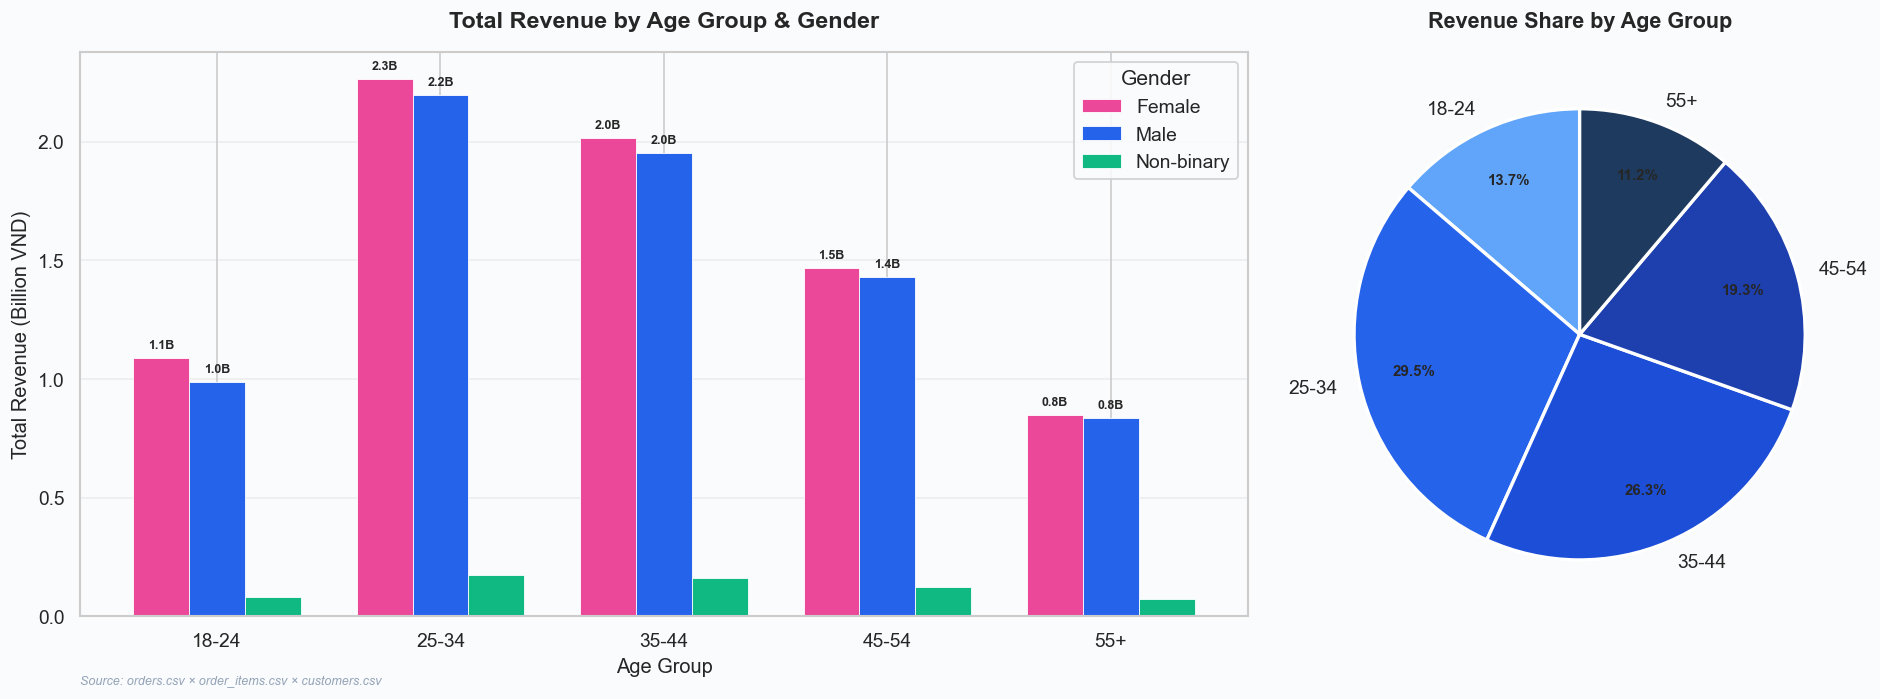


📊 Revenue breakdown (Billion VND):


gender,Female,Male,Non-binary
age_group,,,
18-24,1.09,0.99,0.08
25-34,2.26,2.19,0.17
35-44,2.01,1.95,0.16
45-54,1.47,1.43,0.12
55+,0.85,0.83,0.07



→ Nhóm 25-34 chiếm 29.5% tổng doanh thu


In [4]:
# ── Chart 2.1: Revenue by Age Group × Gender ─────────────
age_order = ['18-24', '25-34', '35-44', '45-54', '55+']
rev_age_gender = (cust_agg[cust_agg['age_group'].notna()]
    .groupby(['age_group', 'gender'])['total_revenue']
    .sum()
    .unstack(fill_value=0)
    .reindex(age_order)
) / 1e9  # đổi sang tỷ VND

fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [2, 1]})

# Left: Grouped bar chart
ax = axes[0]
x = np.arange(len(age_order))
w = 0.25
gender_colors = {'Female': '#EC4899', 'Male': '#2563EB', 'Non-binary': '#10B981'}

for i, gender in enumerate(['Female', 'Male', 'Non-binary']):
    vals = rev_age_gender[gender].values
    bars = ax.bar(x + i*w, vals, w, label=gender, color=gender_colors[gender],
                  edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, vals):
        if val > 0.3:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                    f'{val:.1f}B', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xticks(x + w)
ax.set_xticklabels(age_order)
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Total Revenue (Billion VND)', fontsize=12)
ax.set_title('Total Revenue by Age Group & Gender', fontsize=14, fontweight='bold', pad=15)
ax.legend(title='Gender', framealpha=0.9)
ax.grid(axis='y', alpha=0.3)
add_source_note(ax, 'Source: orders.csv × order_items.csv × customers.csv')

# Right: Pie chart of age group share
ax2 = axes[1]
age_total = rev_age_gender.sum(axis=1)
colors_age = ['#60A5FA', '#2563EB', '#1D4ED8', '#1E40AF', '#1E3A5F']
wedges, texts, autotexts = ax2.pie(
    age_total, labels=age_order, autopct='%1.1f%%',
    colors=colors_age, startangle=90, pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for t in autotexts:
    t.set_fontsize(9)
    t.set_fontweight('bold')
ax2.set_title('Revenue Share by Age Group', fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(FIG_DIR + 'story2_chart1_age_gender_revenue.png', bbox_inches='tight')
plt.show()

# Print data table
print('\n📊 Revenue breakdown (Billion VND):')
display(rev_age_gender.round(2))
print(f'\n→ Nhóm 25-34 chiếm {age_total["25-34"]/age_total.sum()*100:.1f}% tổng doanh thu')

---
### Chart 2.2 — Acquisition Channel Effectiveness

**Mục đích (Diagnostic):** Kênh nào mang lại khách hàng **chất lượng** nhất? (không phải volume)

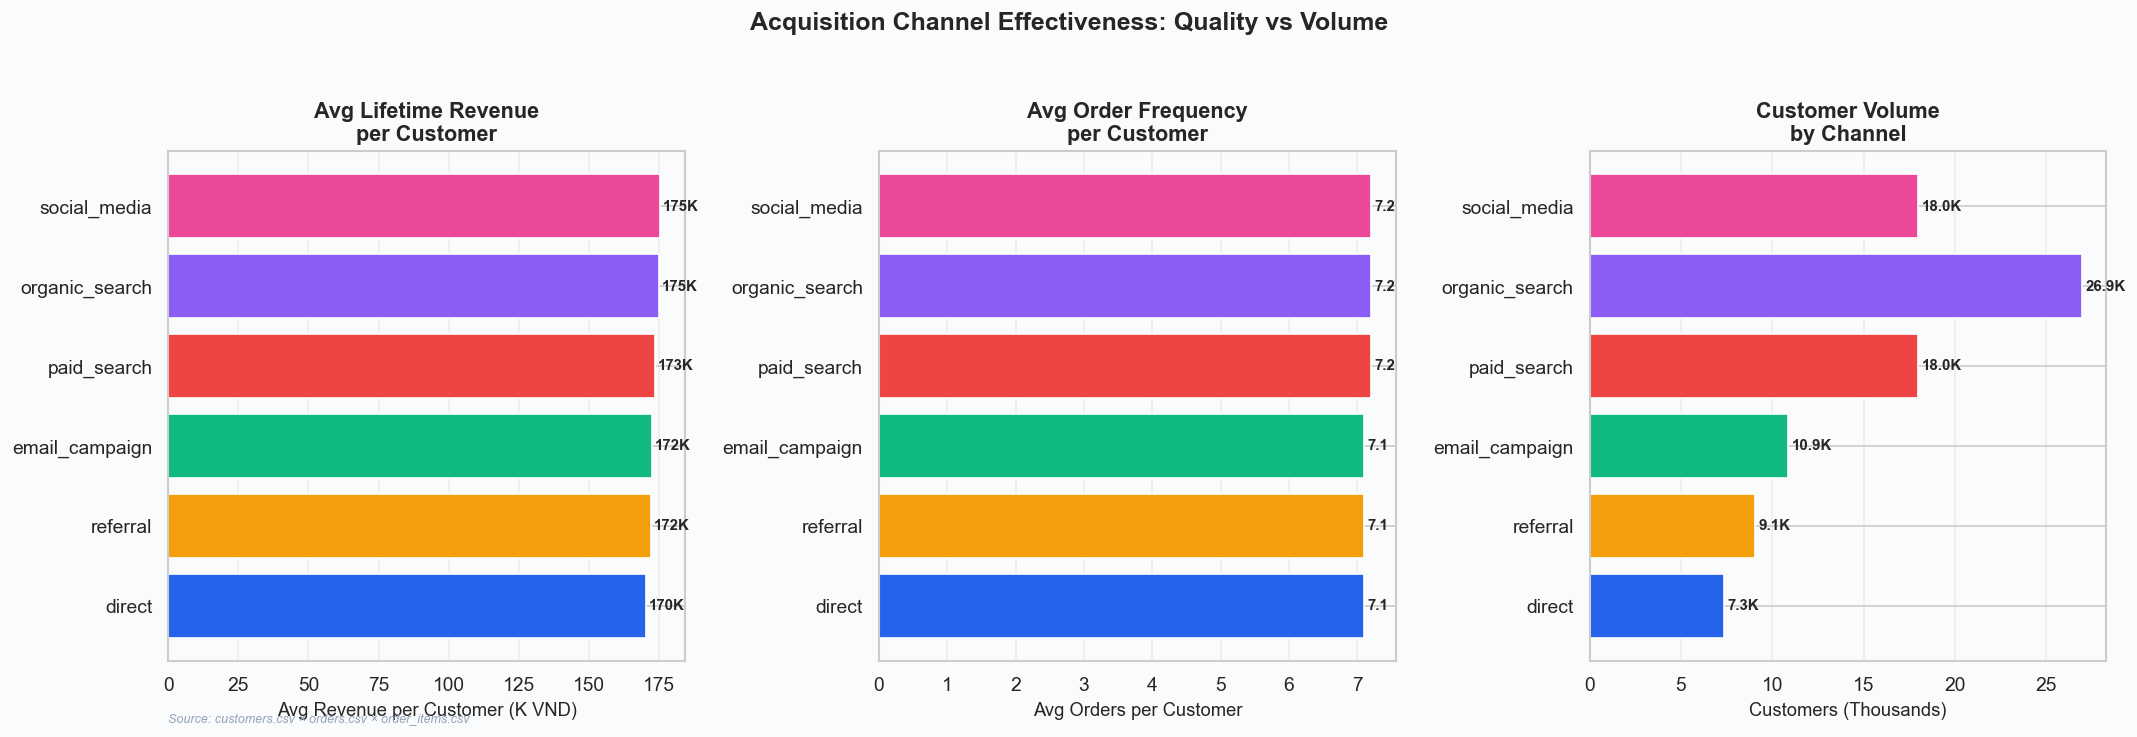


📊 Channel comparison:


,n_customers,avg_orders,avg_revenue,avg_aov
acquisition_channel,,,,
social_media,18002,7.2,175458.1,24197.6
organic_search,26950,7.2,174849.3,24096.5
paid_search,17999,7.2,173475.2,24037.1
email_campaign,10886,7.1,172414.7,23751.7
referral,9072,7.1,171955.6,24113.7
direct,7337,7.1,170480.6,23860.1


In [5]:
# ── Chart 2.2: Acquisition Channel Quality ───────────────
channel_metrics = cust_agg.groupby('acquisition_channel').agg(
    n_customers     = ('customer_id', 'count'),
    avg_orders      = ('total_orders', 'mean'),
    avg_revenue     = ('total_revenue', 'mean'),
    avg_aov         = ('aov', 'mean'),
    avg_items       = ('total_items', 'mean'),
    avg_tenure      = ('tenure_days', 'mean'),
    total_revenue   = ('total_revenue', 'sum'),
).round(1)

channel_metrics = channel_metrics.sort_values('avg_revenue', ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Chart A: Avg Revenue per Customer
ax = axes[0]
bars = ax.barh(channel_metrics.index, channel_metrics['avg_revenue'] / 1e3,
               color=PALETTE[:len(channel_metrics)], edgecolor='white')
ax.set_xlabel('Avg Revenue per Customer (K VND)', fontsize=11)
ax.set_title('Avg Lifetime Revenue\nper Customer', fontsize=13, fontweight='bold')
for bar, val in zip(bars, channel_metrics['avg_revenue'] / 1e3):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}K', ha='left', va='center', fontsize=9, fontweight='bold')

# Chart B: Avg Orders per Customer
ax = axes[1]
bars = ax.barh(channel_metrics.index, channel_metrics['avg_orders'],
               color=PALETTE[:len(channel_metrics)], edgecolor='white')
ax.set_xlabel('Avg Orders per Customer', fontsize=11)
ax.set_title('Avg Order Frequency\nper Customer', fontsize=13, fontweight='bold')
for bar, val in zip(bars, channel_metrics['avg_orders']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', ha='left', va='center', fontsize=9, fontweight='bold')

# Chart C: Number of Customers (Volume)
ax = axes[2]
bars = ax.barh(channel_metrics.index, channel_metrics['n_customers'] / 1e3,
               color=PALETTE[:len(channel_metrics)], edgecolor='white')
ax.set_xlabel('Customers (Thousands)', fontsize=11)
ax.set_title('Customer Volume\nby Channel', fontsize=13, fontweight='bold')
for bar, val in zip(bars, channel_metrics['n_customers'] / 1e3):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}K', ha='left', va='center', fontsize=9, fontweight='bold')

for ax in axes:
    ax.grid(axis='x', alpha=0.3)

add_source_note(axes[0], 'Source: customers.csv × orders.csv × order_items.csv')
plt.suptitle('Acquisition Channel Effectiveness: Quality vs Volume',
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(FIG_DIR + 'story2_chart2_acquisition_channel.png', bbox_inches='tight')
plt.show()

print('\n📊 Channel comparison:')
display(channel_metrics[['n_customers','avg_orders','avg_revenue','avg_aov']].sort_values('avg_revenue', ascending=False))

---
### Chart 2.3 — Customer Cohort Analysis (Signup Year)

**Mục đích (Diagnostic):** Cohort nào có engagement tốt nhất? Chất lượng khách hàng mới có đang giảm?

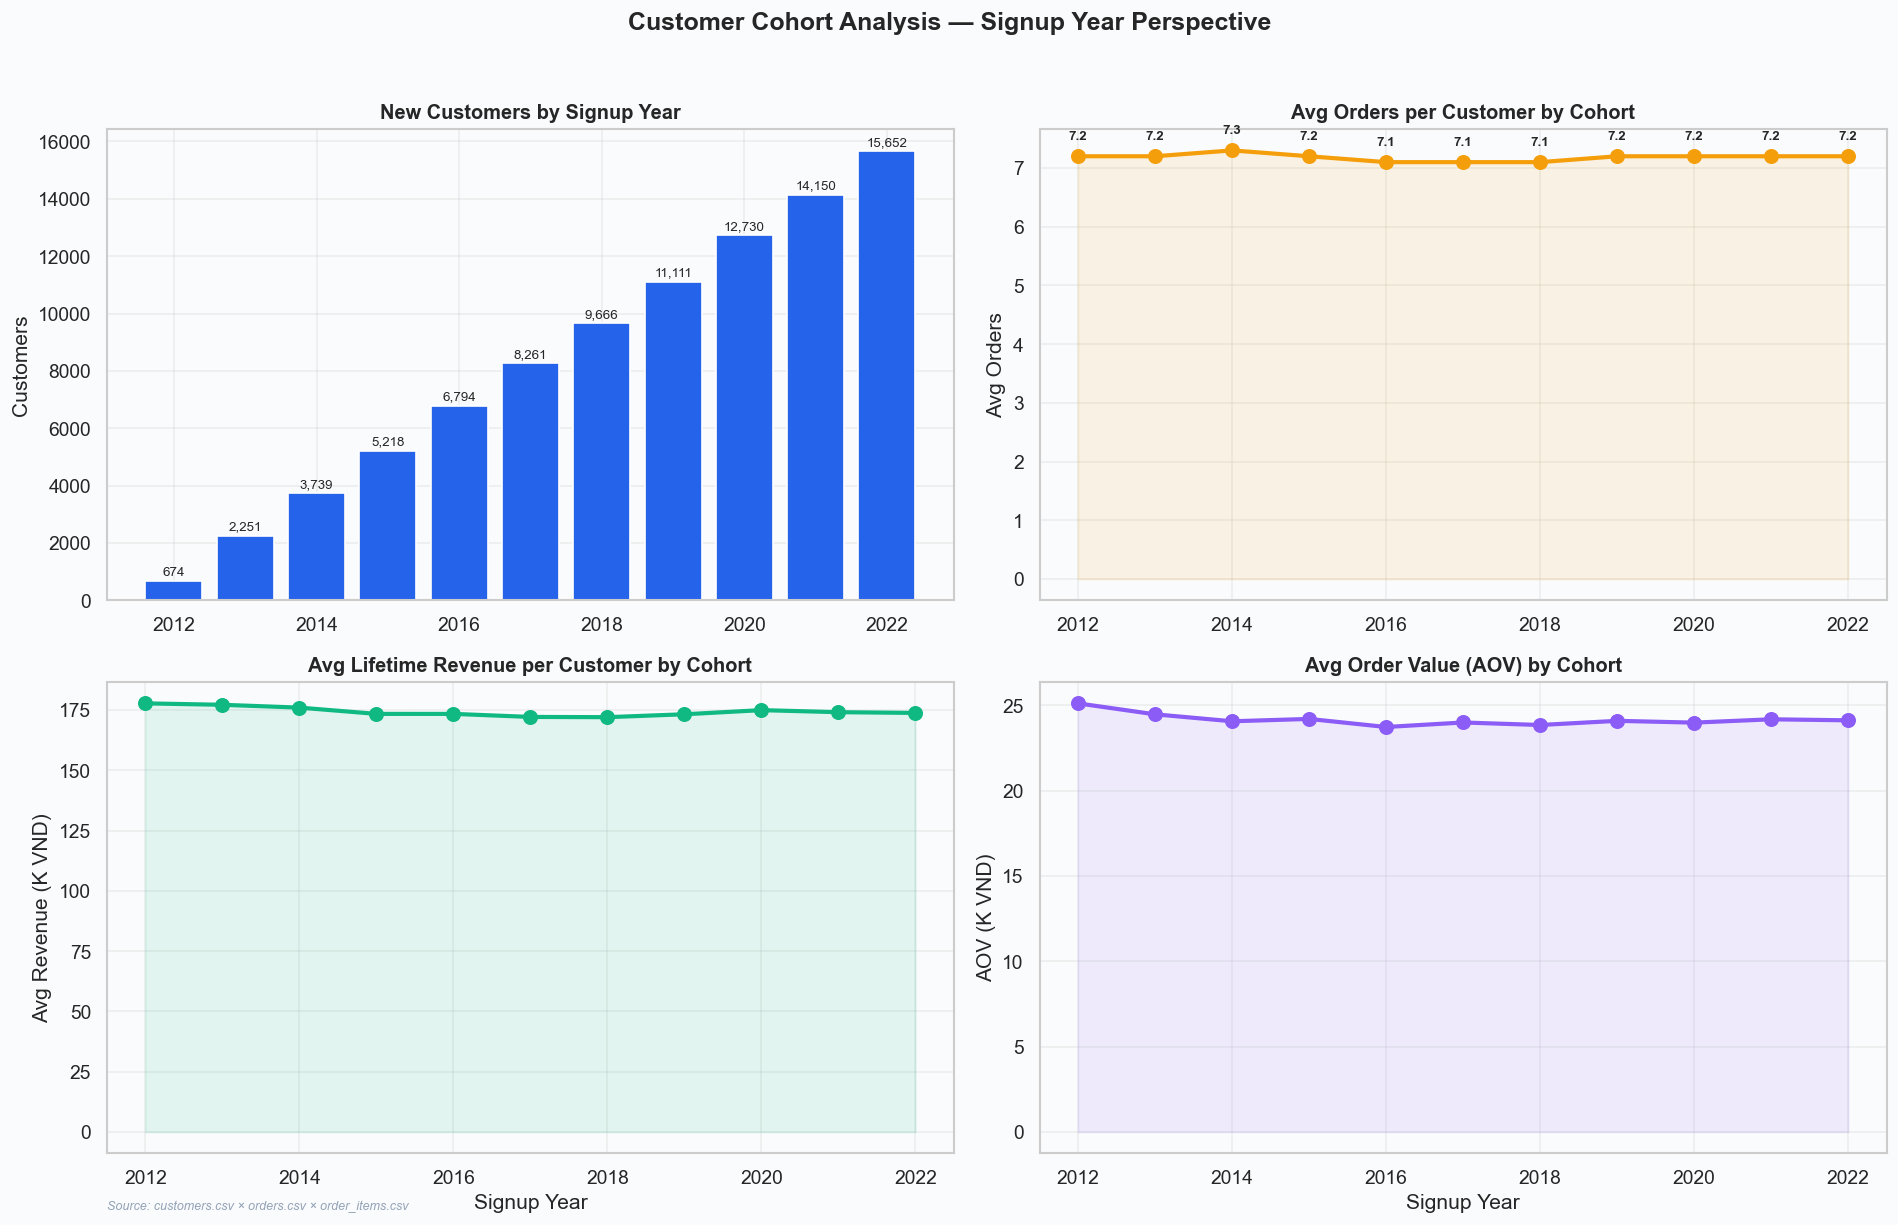


📊 Cohort breakdown:


,n_customers,avg_orders,avg_revenue,avg_aov,median_tenure
signup_year,,,,,
2012,674,7.2,177760.0,25103.0,1863.0
2013,2251,7.2,177173.7,24461.8,1989.0
2014,3739,7.3,176008.1,24055.1,1937.0
2015,5218,7.2,173406.1,24192.5,1942.0
2016,6794,7.1,173401.8,23720.0,1865.5
2017,8261,7.1,172140.2,23984.1,1962.0
2018,9666,7.1,172042.5,23836.9,1967.0
2019,11111,7.2,173245.8,24080.6,1923.0
2020,12730,7.2,174955.3,23976.0,1902.5


In [6]:
# ── Chart 2.3: Cohort Analysis ───────────────────────────
cust_agg['signup_year'] = cust_agg['signup_date'].dt.year

cohort = cust_agg.groupby('signup_year').agg(
    n_customers   = ('customer_id', 'count'),
    avg_orders    = ('total_orders', 'mean'),
    avg_revenue   = ('total_revenue', 'mean'),
    avg_aov       = ('aov', 'mean'),
    median_tenure = ('tenure_days', 'median'),
).round(1)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# A: Customer count by cohort
ax = axes[0, 0]
bars = ax.bar(cohort.index, cohort['n_customers'], color=COLORS['primary'], edgecolor='white')
ax.set_title('New Customers by Signup Year', fontweight='bold', fontsize=12)
ax.set_ylabel('Customers')
for bar, val in zip(bars, cohort['n_customers']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}', ha='center', va='bottom', fontsize=8)

# B: Avg Orders per customer by cohort
ax = axes[0, 1]
ax.plot(cohort.index, cohort['avg_orders'], 'o-', color=COLORS['secondary'],
        linewidth=2.5, markersize=8)
ax.set_title('Avg Orders per Customer by Cohort', fontweight='bold', fontsize=12)
ax.set_ylabel('Avg Orders')
ax.fill_between(cohort.index, cohort['avg_orders'], alpha=0.1, color=COLORS['secondary'])
for x, y in zip(cohort.index, cohort['avg_orders']):
    ax.annotate(f'{y:.1f}', (x, y), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=8, fontweight='bold')

# C: Avg Revenue per customer by cohort
ax = axes[1, 0]
ax.plot(cohort.index, cohort['avg_revenue'] / 1e3, 'o-', color=COLORS['success'],
        linewidth=2.5, markersize=8)
ax.set_title('Avg Lifetime Revenue per Customer by Cohort', fontweight='bold', fontsize=12)
ax.set_ylabel('Avg Revenue (K VND)')
ax.set_xlabel('Signup Year')
ax.fill_between(cohort.index, cohort['avg_revenue'] / 1e3, alpha=0.1, color=COLORS['success'])

# D: AOV by cohort
ax = axes[1, 1]
ax.plot(cohort.index, cohort['avg_aov'] / 1e3, 'o-', color=COLORS['purple'],
        linewidth=2.5, markersize=8)
ax.set_title('Avg Order Value (AOV) by Cohort', fontweight='bold', fontsize=12)
ax.set_ylabel('AOV (K VND)')
ax.set_xlabel('Signup Year')
ax.fill_between(cohort.index, cohort['avg_aov'] / 1e3, alpha=0.1, color=COLORS['purple'])

for ax in axes.flat:
    ax.grid(alpha=0.3)

add_source_note(axes[1, 0], 'Source: customers.csv × orders.csv × order_items.csv')
plt.suptitle('Customer Cohort Analysis — Signup Year Perspective',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR + 'story2_chart3_cohort.png', bbox_inches='tight')
plt.show()

print('\n📊 Cohort breakdown:')
display(cohort)

---
### Chart 2.4 — Churn Risk Distribution

**Mục đích (Predictive):** Bao nhiêu % khách hàng có nguy cơ churn? Ngưỡng cảnh báo nên đặt ở đâu?

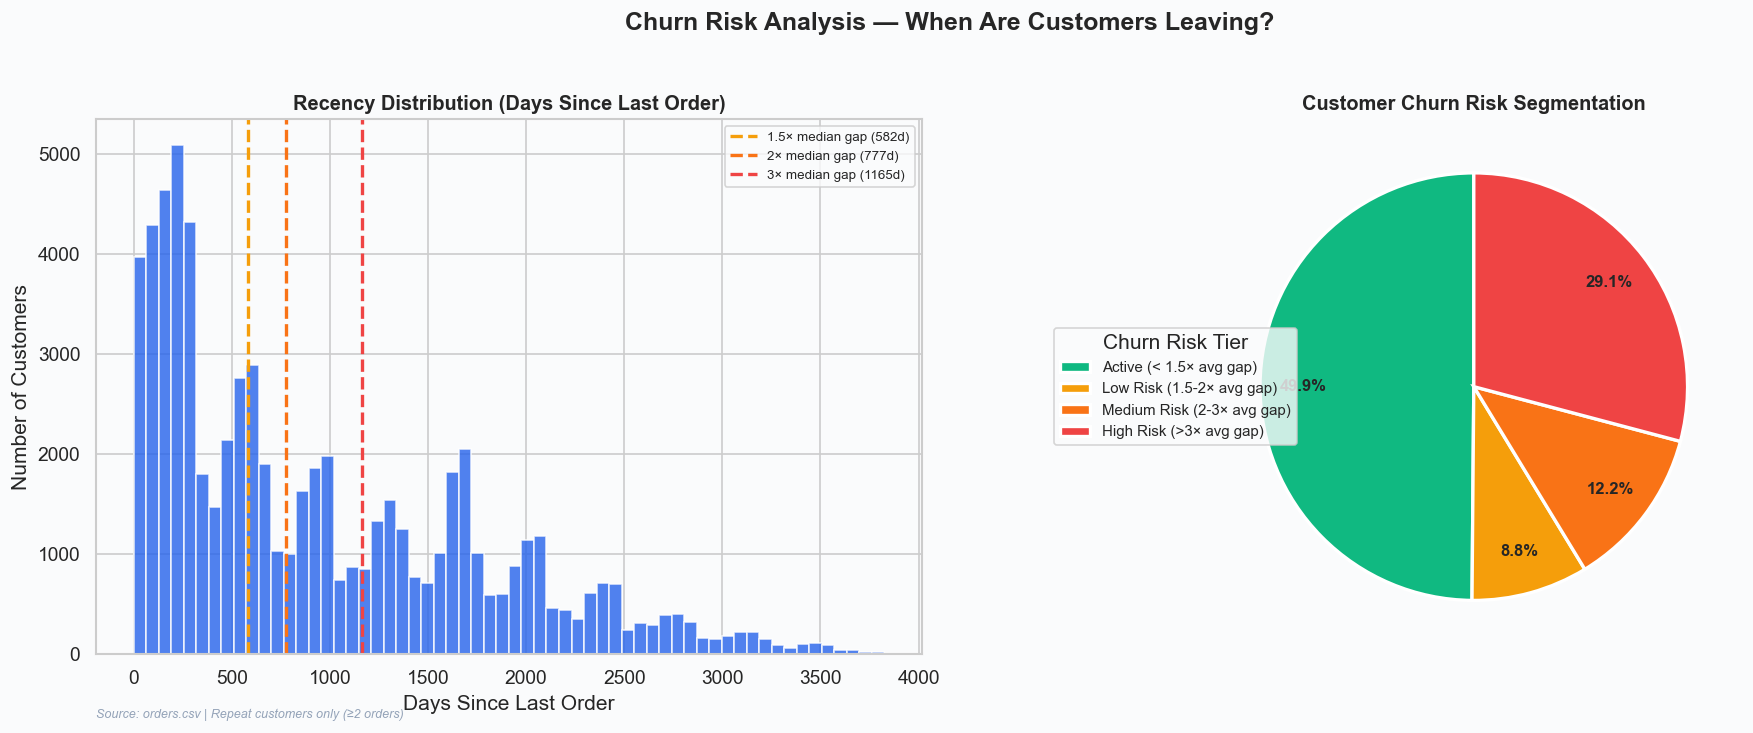


📊 Churn risk breakdown:
  Active (< 1.5× avg gap): 33,853 customers (49.9%) — 8.04B VND revenue at risk
  Low Risk (1.5-2× avg gap): 5,994 customers (8.8%) — 1.46B VND revenue at risk
  Medium Risk (2-3× avg gap): 8,271 customers (12.2%) — 1.90B VND revenue at risk
  High Risk (>3× avg gap): 19,770 customers (29.1%) — 3.74B VND revenue at risk


In [7]:
# ── Chart 2.4: Churn Risk ────────────────────────────────
# Chỉ xét khách hàng có >= 2 đơn (để có inter-order gap)
repeat_cust = cust_agg[cust_agg['total_orders'] > 1].copy()

# Compute average inter-order gap per customer
order_sorted = orders.sort_values(['customer_id', 'order_date'])
order_sorted['gap'] = order_sorted.groupby('customer_id')['order_date'].diff().dt.days
avg_gap = order_sorted.groupby('customer_id')['gap'].mean().reset_index()
avg_gap.columns = ['customer_id', 'avg_gap_days']

repeat_cust = repeat_cust.merge(avg_gap, on='customer_id', how='left')

# Define churn risk tiers
def churn_tier(row):
    if row['recency_days'] > row['avg_gap_days'] * 3:
        return 'High Risk (>3× avg gap)'
    elif row['recency_days'] > row['avg_gap_days'] * 2:
        return 'Medium Risk (2-3× avg gap)'
    elif row['recency_days'] > row['avg_gap_days'] * 1.5:
        return 'Low Risk (1.5-2× avg gap)'
    else:
        return 'Active (< 1.5× avg gap)'

repeat_cust['churn_tier'] = repeat_cust.apply(churn_tier, axis=1)

tier_order = ['Active (< 1.5× avg gap)', 'Low Risk (1.5-2× avg gap)',
              'Medium Risk (2-3× avg gap)', 'High Risk (>3× avg gap)']
tier_colors = [COLORS['success'], COLORS['secondary'], '#F97316', COLORS['danger']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Recency distribution histogram
ax = axes[0]
ax.hist(repeat_cust['recency_days'], bins=60, color=COLORS['primary'],
        edgecolor='white', alpha=0.8)
# Add threshold lines
median_gap = repeat_cust['avg_gap_days'].median()
for mult, col, label in [(1.5, '#F59E0B', '1.5× median gap'),
                          (2.0, '#F97316', '2× median gap'),
                          (3.0, '#EF4444', '3× median gap')]:
    ax.axvline(median_gap * mult, color=col, linestyle='--', linewidth=2, label=f'{label} ({median_gap*mult:.0f}d)')

ax.set_title('Recency Distribution (Days Since Last Order)', fontweight='bold', fontsize=12)
ax.set_xlabel('Days Since Last Order')
ax.set_ylabel('Number of Customers')
ax.legend(fontsize=8, loc='upper right')

# Right: Churn tier pie chart
ax = axes[1]
tier_counts = repeat_cust['churn_tier'].value_counts().reindex(tier_order)
wedges, texts, autotexts = ax.pie(
    tier_counts, labels=None, autopct='%1.1f%%',
    colors=tier_colors, startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    pctdistance=0.8
)
for t in autotexts:
    t.set_fontsize(10)
    t.set_fontweight('bold')
ax.legend(tier_order, title='Churn Risk Tier', loc='center left',
          bbox_to_anchor=(-0.3, 0.5), fontsize=9)
ax.set_title('Customer Churn Risk Segmentation', fontweight='bold', fontsize=12)

add_source_note(axes[0], 'Source: orders.csv | Repeat customers only (≥2 orders)')

plt.suptitle('Churn Risk Analysis — When Are Customers Leaving?',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR + 'story2_chart4_churn_risk.png', bbox_inches='tight')
plt.show()

print('\n📊 Churn risk breakdown:')
for tier in tier_order:
    n = tier_counts.get(tier, 0)
    pct = n / tier_counts.sum() * 100
    rev = repeat_cust[repeat_cust['churn_tier'] == tier]['total_revenue'].sum() / 1e9
    print(f'  {tier}: {n:,} customers ({pct:.1f}%) — {rev:.2f}B VND revenue at risk')

---
### Chart 2.5 — Revenue by Region

**Mục đích (Descriptive + Prescriptive):** Phân bổ doanh thu theo vùng. Vùng nào cần tập trung?

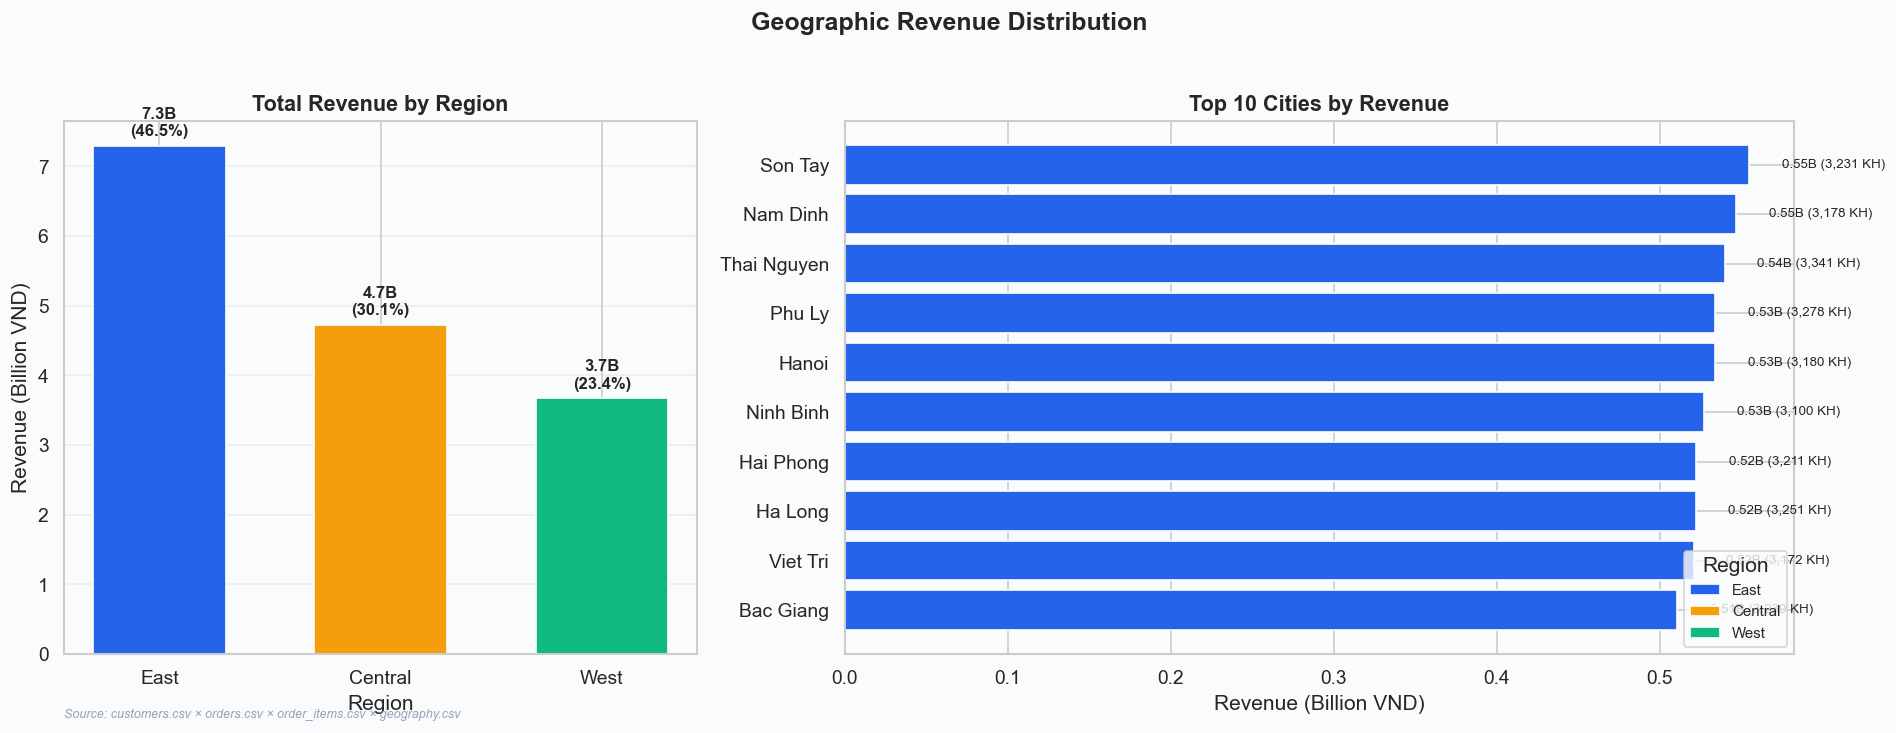


📊 Region metrics:


,n_customers,total_revenue,avg_revenue,avg_orders
region,,,,
East,44721,7.291151e+09,163036.4,6.6
Central,30784,4.719491e+09,153309.9,6.0
West,14741,3.670227e+09,248980.9,11.4


In [8]:
# ── Chart 2.5: Revenue by Region × Top Cities ────────────
region_rev = cust_agg.groupby('region').agg(
    n_customers   = ('customer_id', 'count'),
    total_revenue = ('total_revenue', 'sum'),
    avg_revenue   = ('total_revenue', 'mean'),
    avg_orders    = ('total_orders', 'mean'),
).sort_values('total_revenue', ascending=False)

# Top cities by revenue per region
city_rev = cust_agg.groupby(['region', 'city']).agg(
    total_revenue = ('total_revenue', 'sum'),
    n_customers   = ('customer_id', 'count'),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1, 1.5]})

# Left: Region revenue bar
ax = axes[0]
region_colors = {'East': COLORS['primary'], 'Central': COLORS['secondary'], 'West': COLORS['success']}
bars = ax.bar(region_rev.index,
              region_rev['total_revenue'] / 1e9,
              color=[region_colors.get(r, '#999') for r in region_rev.index],
              edgecolor='white', width=0.6)

for bar, (_, row) in zip(bars, region_rev.iterrows()):
    pct = row['total_revenue'] / region_rev['total_revenue'].sum() * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{row["total_revenue"]/1e9:.1f}B\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Total Revenue by Region', fontweight='bold', fontsize=13)
ax.set_ylabel('Revenue (Billion VND)')
ax.set_xlabel('Region')
ax.grid(axis='y', alpha=0.3)

# Right: Top 10 cities by revenue
ax = axes[1]
top_cities = city_rev.nlargest(10, 'total_revenue').sort_values('total_revenue')
bar_colors = [region_colors.get(r, '#999') for r in top_cities['region']]
bars = ax.barh(top_cities['city'], top_cities['total_revenue'] / 1e9,
               color=bar_colors, edgecolor='white')

for bar, (_, row) in zip(bars, top_cities.iterrows()):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{row["total_revenue"]/1e9:.2f}B ({row["n_customers"]:,} KH)',
            ha='left', va='center', fontsize=8)

ax.set_title('Top 10 Cities by Revenue', fontweight='bold', fontsize=13)
ax.set_xlabel('Revenue (Billion VND)')

# Add region legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=r) for r, c in region_colors.items()]
ax.legend(handles=legend_elements, title='Region', loc='lower right', fontsize=9)

add_source_note(axes[0], 'Source: customers.csv × orders.csv × order_items.csv × geography.csv')

plt.suptitle('Geographic Revenue Distribution',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR + 'story2_chart5_region_revenue.png', bbox_inches='tight')
plt.show()

print('\n📊 Region metrics:')
display(region_rev.round(1))

---
## 📝 Story 2: Phân tích 4 cấp độ — Customer Segmentation

### 🔵 DESCRIPTIVE — Chuyện gì đang xảy ra?

- Tổng **90,246 khách hàng** với TB **7.2 đơn/khách**, AOV **~24,000 VND**
- Nhóm **25-34 tuổi** chiếm lớn nhất về revenue (**29.5%**), tiếp theo là **35-44** (**26.3%**)
- Giới tính phân bổ khá đều: Female ~49%, Male ~47%, Non-binary ~4%
- Vùng **East** đóng góp **7.3B VND (46.5%)** tổng doanh thu, gấp ~2× West
- Kênh **organic_search** mang nhiều khách nhất (26.9K), nhưng chất lượng tương đương các kênh khác

### 🟡 DIAGNOSTIC — Tại sao?

- Tất cả 6 kênh acquisition có **avg revenue/customer gần bằng nhau** (~170-175K VND) → không có kênh nào vượt trội rõ rệt về chất lượng
- Sự khác biệt chủ yếu nằm ở **volume**: organic_search và social_media chiếm ~50% tổng khách hàng
- Cohort analysis cho thấy **avg orders** và **AOV** rất ổn định (~7.1-7.3 đơn, ~24K VND) qua mọi năm đăng ký → pricing strategy nhất quán nhưng thiếu cơ hội upsell
- Top 10 thành phố (Sơn Tây, Nam Định, Thái Nguyên...) đều thuộc vùng **East** → phân bổ địa lý mất cân bằng

### 🟠 PREDICTIVE — Điều gì sẽ xảy ra tiếp?

- Khách hàng có recency > 3× avg inter-order gap → **High Risk churn: 29.1%** (19,770 khách hàng)
- Revenue at risk từ nhóm Medium + High risk = **5.64 tỷ VND** (1.90B Medium + 3.74B High)
- Nhóm Low Risk (8.8%, 5,994 KH) sẽ chuyển sang Medium/High nếu không can thiệp trong 3-6 tháng
- Chỉ **49.9%** khách hàng repeat đang Active → gần **1/2** đã có dấu hiệu rời bỏ
- Với growth rate KH mới ~10%/năm (từ 12.7K năm 2020 lên 15.6K năm 2022), churn rate hiện tại sẽ khiến tổng KH active giảm net

### 🔴 PRESCRIPTIVE — Nên làm gì?

1. **Win-back campaign khẩn cấp**: Gửi email/SMS cho 8,271 KH Medium Risk (2-3× gap) kèm coupon cá nhân hoá (ước tính cứu lại 1.90B VND revenue)
2. **Loyalty program cho nhóm 25-44 tuổi**: Nhóm chiếm 55.8% revenue, tập trung giữ chân bằng membership tiers (Silver/Gold/Platinum)
3. **Đa dạng hoá kênh acquisition**: Tăng đầu tư social_media và paid_search (volume cao, chất lượng tương đương organic)
4. **Mở rộng vùng West & Central**: Revenue/customer ở West thấp hơn East → cần khai thác thêm các thành phố Central/West chưa có độ phủ
5. **Onboarding chuyên sâu cho cohort mới (2021-2022)**: Welcome email series + first-purchase discount + cross-sell gợi ý category mới để tăng n_categories/KH
6. **Tối ưu upsell/cross-sell**: AOV phẳng ~24K qua mọi cohort → cần bundle offers, "mua kèm giảm thêm" để tăng giá trị đơn hàng